In [1]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
import seawater as sw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/sitecustomize.py:72: UserWarning: The seawater library is deprecated! Please use gsw instead.
  mod = _real_import(name, globals, locals, fromlist, level)


In [2]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [ ]:
path_load = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/output/'
ds = xr.open_dataset(path_load + 'mean_26years.nc')

Ta_mean            = ds.Ta_mean.load()
wind_speed_mean    = ds.wind_speed_mean.load()
precipitation_mean = ds.precipitation_mean.load()
evaporation_mean   = ds.evaporation_mean.load()
sshf_mean          = ds.sshf_mean.load()
slhf_mean          = ds.slhf_mean.load()
tcc_mean           = ds.tcc_mean.load()
SST_mean           = ds.SST_mean.load()

lon_ERA5, lat_ERA5 = ds.lon_ERA5, ds.lat_ERA5
lon_SST, lat_SST   = ds.lon_SST, ds.lat_SST

In [ ]:
# path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
# time_sel = slice('1993-01-01', '2019-05-31')
# SST  = xr.open_dataset(path+'sst_19820101-20211231_fromChrisC.nc').sst.load()[:,0]
# SST = SST.sel().sel(time=time_sel)
# lon_SST, lat_SST = SST.lon, SST.lat

In [ ]:
# SST_mean = SST.mean('time').compute()

In [3]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
###################################################################
front_boundary = argnear(lon_front, 65)[0]
lon_front      = lon_front[:front_boundary]
lat_front      = lat_front[:,:front_boundary]
lat_front_mean = np.nanmean(lat_front, axis = 0)


/jobfs/171696192.gadi-pbs/ipykernel_694483/2624704074.py:16: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front, axis = 0)


In [4]:
# lat_crest_1, lon_crest_1   = -40.5, 25.3
# lat_crest_2, lon_crest_2   = -40.4, 31
# lat_crest_4, lon_crest_4   = -41.5, 52.3
# lat_crest_7, lon_crest_7   = -44.3, 62.3
# ############### TROUGHS
# lat_trough_1, lon_trough_1 = -38.2, 27.8
# lat_trough_2, lon_trough_2 = -37.7, 32.3
# lat_trough_3, lon_trough_3 = -39.5, 38

In [17]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38
lat_trough_4, lon_trough_4 = -39.5, 50

## Figure S1

In [30]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
extent = [19.99, 65.01, -47, -30.5]

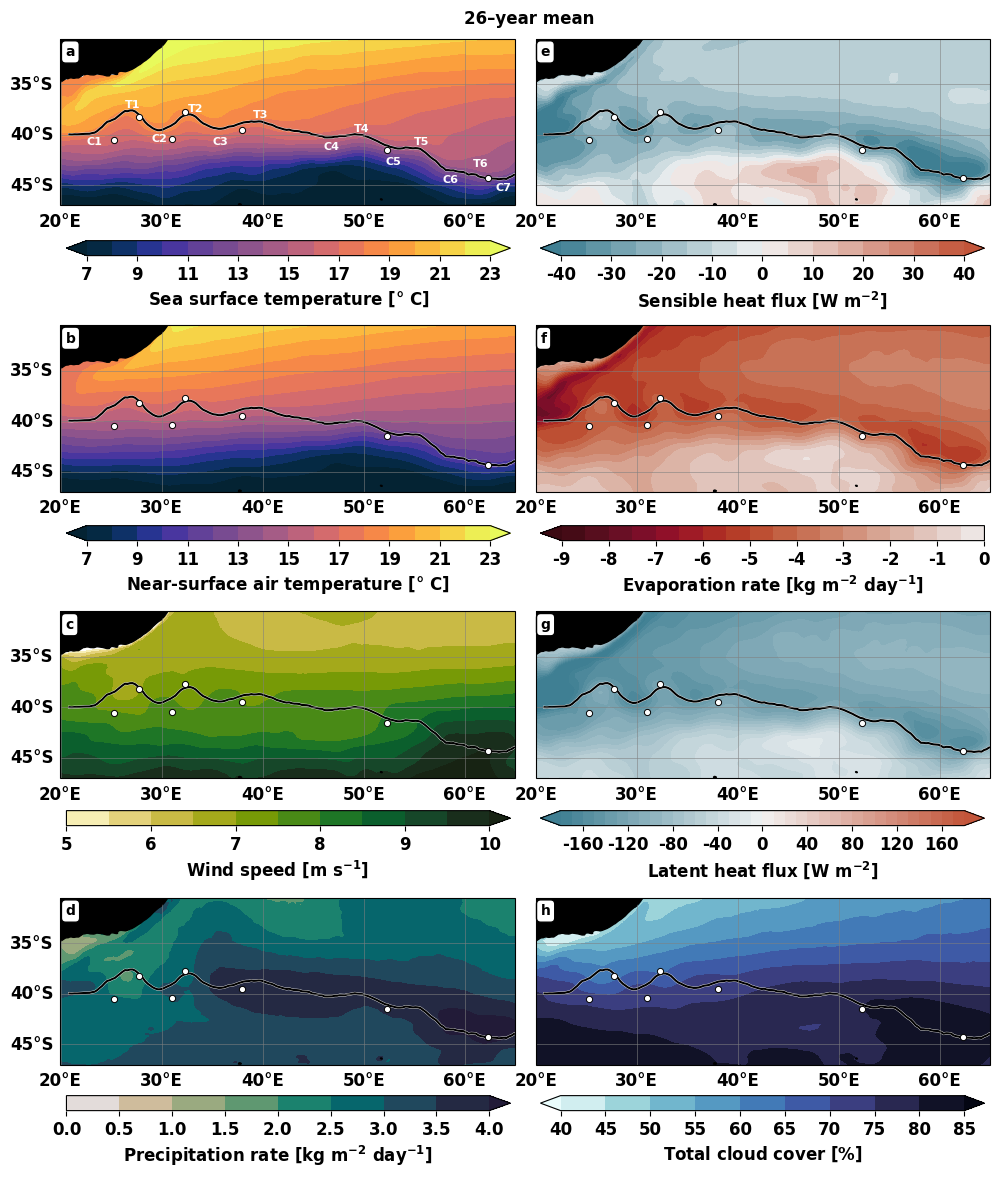

In [10]:
fig = plt.figure(figsize = (12,15))
grd = GridSpec(101,100)
extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

####################### FIGURE 
ax = [fig.add_subplot(grd[:24,:49], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[25:49,:49], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:74,:49], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[75:99,:49], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[:24,51:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[25:49,51:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[50:74,51:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[75:99,51:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon_SST, lat_SST, SST_mean, np.arange(7, 24, 1), cmap = cm.thermal, extend = 'both')
cf2 = ax[1].contourf(lon_ERA5, lat_ERA5, Ta_mean, np.arange(7, 24, 1), cmap = cm.thermal, extend = 'both')
cf3 = ax[2].contourf(lon_ERA5, lat_ERA5, wind_speed_mean, np.arange(5,10.5,.5), cmap = cm.speed, extend = 'max')
cf4 = ax[3].contourf(lon_ERA5, lat_ERA5, precipitation_mean, np.arange(0,4.5,.5), cmap = cm.rain, extend = 'max')
cf5 = ax[4].contourf(lon_ERA5, lat_ERA5, sshf_mean, np.arange(-40,45,5), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend = 'both')
cf6 = ax[5].contourf(lon_ERA5, lat_ERA5, evaporation_mean, np.arange(-9,.5,.5), cmap = cm.amp_r, extend = 'min')
cf7 = ax[6].contourf(lon_ERA5, lat_ERA5, slhf_mean, np.arange(-180,190,10), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend = 'both')
cf8 = ax[7].contourf(lon_ERA5, lat_ERA5, tcc_mean, np.arange(40,90,5), cmap = cm.ice_r, extend = 'both')

txt = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
ax[0].annotate(text='26–year mean', color='k', xy=(59.9,-29), xycoords='data', zorder = 300) 
for i in range(len(ax)):
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 2)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 1.5)
    ax[i].annotate(text=txt[i], color='k', xy=(20.5,-32.2), xycoords='data', bbox=props, fontsize = 10, zorder = 300) 
    
    ## Grid
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.bottom_labels = True
    # gl.ylabel_style = {'size': 12}
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 5))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 10))
    if i > 3:
        gl.left_labels = False

    ### Some annotation
    ft = 8
    if i == 0:
        # ax[i].annotate(text='Meander', color='k', xy=(40.6,-41.2), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
        ax[i].annotate(text='C1', color='w', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T1', color='w', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C2', color='w', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T2', color='w', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C3', color='w', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T3', color='w', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C4', color='w', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T4', color='w', xy=(49,-39.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C5', color='w', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T5', color='w', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C6', color='w', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T6', color='w', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C7', color='w', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)
    
    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)

bar = plt.axes([0.13, 0.7, 0.37, 0.01])
cbar = plt.colorbar(cf1, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Sea surface temperature [$\degree$ C]')
################################################################
bar = plt.axes([0.13, 0.7-.19, 0.37, 0.01])
cbar = plt.colorbar(cf2, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Near-surface air temperature [$\degree$ C]')
################################################################
bar = plt.axes([0.13, 0.7-.19*2, 0.37, 0.01])
cbar = plt.colorbar(cf3, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Wind speed [m s$^{-1}$]')
################################################################
bar = plt.axes([0.13, 0.7-.19*3, 0.37, 0.01])
cbar = plt.colorbar(cf4, cax = bar, orientation = 'horizontal', format='%.1f') 
cbar.set_label('Precipitation rate [kg m$^{-2}$ day$^{-1}$]')
################################################################
bar = plt.axes([0.525, 0.7, 0.37, 0.01])
cbar = plt.colorbar(cf5, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Sensible heat flux [W m$^{-2}$]')
################################################################
bar = plt.axes([0.525, 0.7-.19, 0.37, 0.01])
cbar = plt.colorbar(cf6, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Evaporation rate [kg m$^{-2}$ day$^{-1}$]')
################################################################
bar = plt.axes([0.525, 0.7-.19*2, 0.37, 0.01])
cbar = plt.colorbar(cf7, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Latent heat flux [W m$^{-2}$]')
################################################################
bar = plt.axes([0.525, 0.7-.19*3, 0.37, 0.01])
cbar = plt.colorbar(cf8, cax = bar, orientation = 'horizontal', format='%.0f') 
cbar.set_label('Total cloud cover [$\%$]')

plt.savefig(path_fig + 'Fig_S1.jpg', dpi =300, bbox_inches = 'tight')

## Figure S3

In [5]:
path_load = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
ds = xr.open_dataset(path_load + 'SLA_trend_26years.nc')

SST_data  = xr.open_dataset(path_load+'SST_trend_26years.nc')
SST_trend = SST_data.slope_decade_SST.load()
SST_lon, SST_lat = SST_data.longitude, SST_data.latitude

In [15]:
path_load = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/output/'
data = xr.open_dataset(path_load+'cloud_trend_26years.nc')
lon, lat = data.longitude, data.latitude
slope_decade_cloud, p_value_cloud = data.slope_decade_Ta, data.p_value_Ta
##########################################################################
ds = xr.open_dataset(path_load+'ea.ans.trend.1993to2019.nearsfc.diab.nc')
slope_decade_diab, p_value_diab = ds.diab_trend*86400, ds.diab_trend_pvalue

In [10]:
path_load = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/scripts/trends/output/'
ds        = xr.open_dataset(path_load+'ppt_evap_shf_lhf_trends_26years.nc')
lon, lat  = ds.longitude, ds.latitude
#####################################################################################
slope_decade_evaporation   = ds.slope_decade_evaporation
slope_decade_slhf          = ds.slope_decade_slhf
#####################################################################################
p_value_evaporation   = ds.p_value_evaporation
p_value_slhf           = ds.p_value_slhf

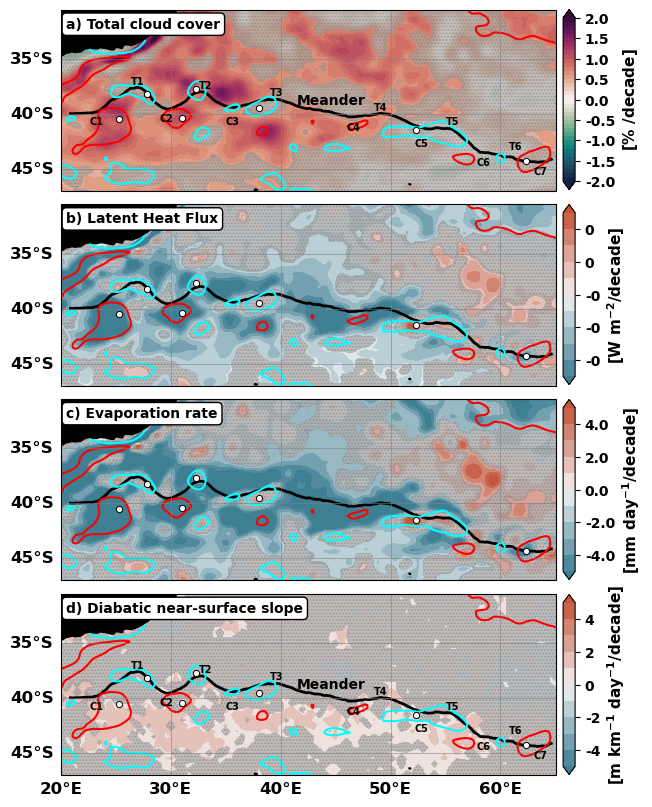

In [32]:
fig = plt.figure(figsize = (12,15))
grd = GridSpec(101,100)
extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')

####################### FIGURE 
ax = [fig.add_subplot(grd[:16,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[17:33,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[34:50,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[51:67,:], projection=ccrs.PlateCarree())]
      # fig.add_subplot(grd[68:84,:], projection=ccrs.PlateCarree()),]

htch = ['.....']
####################### FIGURE 1
cf1 = ax[0].contourf(lon, lat, slope_decade_cloud, np.arange(-2,2.1,.1), cmap = cm.curl, extend='both')
hatch1 = ax[0].contourf(lon, lat, p_value_cloud, [0.05,1], cmap='Greys', hatches=htch, alpha=.5) 
####################### FIGURE 2
cf2 = ax[1].contourf(lon, lat, slope_decade_evaporation, np.arange(-.25,.3,.05), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch2 = ax[1].contourf(lon, lat, p_value_evaporation, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
####################### FIGURE 3
cf3 = ax[2].contourf(lon, lat, slope_decade_slhf, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch3 = ax[2].contourf(lon, lat, p_value_slhf, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 
# ####################### FIGURE 4
cf4 = ax[3].contourf(slope_decade_diab.longitude, slope_decade_diab.latitude, slope_decade_diab*1e3, np.arange(-5,6,1), cmap = sns.diverging_palette(220, 20, as_cmap=True), extend='both')
hatch4 = ax[3].contourf(slope_decade_diab.longitude, slope_decade_diab.latitude, p_value_diab, [0.05,1], cmap='Greys',alpha=.5, hatches=htch) 

cf, cbar_ = [cf1, cf2, cf3, cf4], []
cf_hatch  = [hatch1, hatch2, hatch3, hatch4]
txt = ['a) Total cloud cover', 'b) Latent Heat Flux', 'c) Evaporation rate', 'd) Diabatic near-surface slope']
for i in range(len(ax)):
    line = ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    cr_SST = ax[i].contour(SST_lon, SST_lat, SST_trend, [-.1,.3], colors = ['cyan', 'red'], linestyles = 'solid')
    handles_SST, labels_SST = cr_SST.legend_elements()
    ax[i].annotate(text=txt[i], color='k', xy=(20.5,-32.2), xycoords='data', bbox=props, fontsize = 10, zorder = 300)  

    cf_hatch[i].set_edgecolor('grey')
    cf_hatch[i].set_linewidth(0)   
    ### Some annotation
    ft = 7
    if i == 0 or i == 3:
        ax[i].annotate(text='Meander', color='k', xy=(41.5,-39.1), xycoords='data', fontsize = 10, zorder = 300, fontweight = 'bold')
        ax[i].annotate(text='C1', color='k', xy=(22.6,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T1', color='k', xy=(26.4,-37.35), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C2', color='k', xy=(29,-40.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T2', color='k', xy=(32.6,-37.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C3', color='k', xy=(35,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T3', color='k', xy=(39,-38.3), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C4', color='k', xy=(46,-41.5), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T4', color='k', xy=(48.5,-39.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C5', color='k', xy=(52.2,-43), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T5', color='k', xy=(55,-41), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C6', color='k', xy=(57.8,-44.7), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='T6', color='k', xy=(60.8,-43.2), xycoords='data', fontsize = ft, zorder = 300)
        ax[i].annotate(text='C7', color='k', xy=(63,-45.5), xycoords='data', fontsize = ft, zorder = 300)
    
    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    
    ## Grid
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylabel_style = {'size': 12}
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 5))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 10))

    # Colorbar
    # bar = plt.axes([0.8, 0.698-i*.17-i*.023, 0.01, 0.18])
    bar = plt.axes([0.725, 0.76-i*.12-i*.01, 0.01, 0.12])
    cbar = plt.colorbar(cf[i], cax = bar)  
    cbar.ax.tick_params(labelsize=10) 
    cbar_.append(cbar)
    if i == 0:
        # gl.top_labels = True
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        cbar_[i].set_label(r'[$\%$ /decade]', fontsize = 11)
    if i == 1:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        cbar_[i].set_label(r'[W m$^{-2}$/decade]', fontsize = 11)
    if i == 2:
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        # cbar_[i].set_label(r'[kg m$^{-2}$ day$^{-1}$/decade]', fontsize = 11)
        cbar_[i].set_label(r'[mm day$^{-1}$/decade]', fontsize = 11)
    if i == 3: 
        cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
        cbar_[i].set_label(r'[m km$^{-1}$ day$^{-1}$/decade]', fontsize = 11)

gl.bottom_labels = True


plt.savefig(path_fig + 'Fig_S3.jpg', dpi =300, bbox_inches = 'tight')